In [1]:
# Feline Age Prediction from Spectrograms
!pip install numpy pandas matplotlib seaborn tensorflow keras librosa scikit-learn tensorflow-metal


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
ERROR: Could not find a version that satisfies the requirement tensorflow-metal (from versions: none)

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for tensorflow-metal


In [2]:
import random

import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(tf.__version__)

# Configure Metal (MPS) backend
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Metal GPU available: {gpus}")
    # Allow memory growth to avoid allocating all GPU memory upfront
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No GPU found — running on CPU")

2.21.0
No GPU found — running on CPU


In [3]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path(".").resolve()
EMBEDDINGS_DIR = PROJECT_ROOT / "feline-age-prediction" / "dataset" / "embeddings"

yamnet_path = EMBEDDINGS_DIR / "yamnet_looped_embeddings.csv"
print("YAMNet file exists:", yamnet_path.exists())

orig_embeddings = pd.read_csv(yamnet_path)
orig_embeddings.head()

YAMNet file exists: True


,0,1,2,3,4,5,6,7,8,9,...,1017,1018,1019,1020,1021,1022,1023,gender,target,cat_id
0,0.0,0.000000,1.585768,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,F,6.0,002A
1,0.0,1.304202,2.411754,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,F,10.0,028A
2,0.0,1.128479,0.032892,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,F,3.0,070A
3,0.0,0.069267,0.467173,0.002932,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.359098,0.0,0.0,M,6.0,033A
4,0.0,0.402526,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.268107,0.000000,0.0,0.0,F,2.0,000B


In [28]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path(".").resolve()
RAW_AUDIO_ROOT = PROJECT_ROOT / "feline-age-prediction" / "dataset" / "raw_audio" / "AudioCropped"
print("RAW_AUDIO_ROOT:", RAW_AUDIO_ROOT)

all_files = list(RAW_AUDIO_ROOT.rglob("*.wav"))
print("Found .wav files:", len(all_files))
print("Example:", all_files[0].name)

rows = []
for p in all_files:
    # Example filename: "0.5Y-022A-F1-01.wav"
    stem = p.stem  # "0.5Y-022A-F1-01"
    split = stem.split("-")
    first_part = split[0]  # "0.5Y"

    # parse age in years from prefix like "0.5Y", "12Y", etc.
    if first_part.endswith("Y"):
        age_str = first_part[:-1]
        try:
            age = float(age_str)
        except ValueError:
            age = None
    else:
        age = None

    cat_id = split[1]

    rows.append({"filepath": p, "age": age, "cat_id": cat_id})

df_meta = pd.DataFrame(rows)
df_meta = df_meta.dropna(subset=["age"]).reset_index(drop=True)

print("df_meta shape:", df_meta.shape)
df_meta.head()

RAW_AUDIO_ROOT: /Users/brianslonim/PycharmProjects/deep_purring/feline-age-prediction/dataset/raw_audio/AudioCropped
Found .wav files: 793
Example: 6Y-002A-F4-02.wav
df_meta shape: (793, 3)


,filepath,age,cat_id
0,/Users/brianslonim/PycharmProjects/deep_purrin...,6.0,002A
1,/Users/brianslonim/PycharmProjects/deep_purrin...,10.0,028A
2,/Users/brianslonim/PycharmProjects/deep_purrin...,3.0,070A
3,/Users/brianslonim/PycharmProjects/deep_purrin...,6.0,033A
4,/Users/brianslonim/PycharmProjects/deep_purrin...,2.0,000B


In [5]:
def age_to_age_group(age: float) -> int:
    if age <= 1:
        return 0  # Kitten / young
    elif age <= 10:
        return 1  # Adult / middle
    else:
        return 2  # Senior / old

df_meta["age_group"] = df_meta["age"].apply(age_to_age_group)
df_meta["age_group"].value_counts()

age_group
1    440
0    188
2    165
Name: count, dtype: int64

In [27]:
all_files = list(RAW_AUDIO_ROOT.rglob("*.wav"))
print("Found .wav files:", len(all_files))
if len(all_files) > 0:
    print("Example:", all_files[0].name)

Found .wav files: 793
Example: 6Y-002A-F4-02.wav


In [7]:
# Audio / spectrogram params
SAMPLE_RATE = 96000
DURATION = 2.0          # seconds of audio per example (pad/truncate)
N_MELS = 64
HOP_LENGTH = 256
FMIN = 50
FMAX = 8000

# Model / training params
BATCH_SIZE = 32
EPOCHS = 25
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

In [8]:
AGE_GROUP_CATEGORIES = ["Kitten", "Adult", "Senior"]
NUM_CLASSES = len(AGE_GROUP_CATEGORIES)

def age_to_age_group(age: float) -> int:
    if age <= 1:
        return 0      # Kitten
    elif age <= 10:
        return 1      # Adult
    else:
        return 2      # Senior

def fix_embeddings_labels(embeddings: pd.DataFrame, label_col: str) -> pd.DataFrame:
    new_df = embeddings.rename(columns={"target": "age"})
    new_df["age_group"] = new_df["age"].apply(age_to_age_group)

    # keep only numeric feature columns + the label
    new_df = new_df.drop(
        columns=[col for col in new_df.columns if col != label_col and not col.isnumeric()]
    )

    # drop rows with any missing values
    bad = new_df.isna().any(axis=1)
    new_df = new_df[~bad]

    return new_df

fixed_embeddings = fix_embeddings_labels(orig_embeddings, "age_group")
fixed_embeddings.head()

/var/folders/zp/rr203r4x1vj22lh9pzzc37z80000gn/T/ipykernel_70515/378138232.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_df["age_group"] = new_df["age"].apply(age_to_age_group)


,0,1,2,3,4,5,6,7,8,9,...,1015,1016,1017,1018,1019,1020,1021,1022,1023,age_group
0,0.0,0.000000,1.585768,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1
1,0.0,1.304202,2.411754,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1
2,0.0,1.128479,0.032892,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1
3,0.0,0.069267,0.467173,0.002932,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.359098,0.0,0.0,1
4,0.0,0.402526,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.268107,0.000000,0.0,0.0,1


In [9]:
print("Shape:", fixed_embeddings.shape)

# label distribution
fixed_embeddings["age_group"].value_counts().rename(index={
    0: "Kitten", 1: "Adult", 2: "Senior"
})

Shape: (968, 1025)


age_group
Adult     510
Kitten    248
Senior    210
Name: count, dtype: int64

In [10]:
def load_audio_fixed(path: Path,
                     sample_rate: int = SAMPLE_RATE,
                     duration: float = DURATION) -> np.ndarray:
    target_len = int(sample_rate * duration)
    y, sr = librosa.load(path, sr=sample_rate)

    if len(y) > target_len:
        y = y[:target_len]
    elif len(y) < target_len:
        # pad at end with zeros
        y = np.pad(y, (0, target_len - len(y)), mode="constant")
    return y

def audio_to_mel(y: np.ndarray,
                 sample_rate: int = SAMPLE_RATE,
                 n_mels: int = N_MELS,
                 hop_length: int = HOP_LENGTH,
                 fmin: int = FMIN,
                 fmax: int = FMAX) -> np.ndarray:
    S = librosa.feature.melspectrogram(
        y=y,
        sr=sample_rate,
        n_mels=n_mels,
        hop_length=hop_length,
        fmin=fmin,
        fmax=fmax,
        power=2.0,
    )
    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db



In [11]:
if len(df_meta) == 0:
    raise RuntimeError("df_meta is empty – check FOLDER_TO_GROUP keys vs df_meta['folder'].unique().")

example_path = df_meta["filepath"].iloc[0]
y = load_audio_fixed(example_path)
mel = audio_to_mel(y)

/Users/brianslonim/PycharmProjects/deep_purring/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Wave shape: (192000,)
Mel shape: (64, 751)


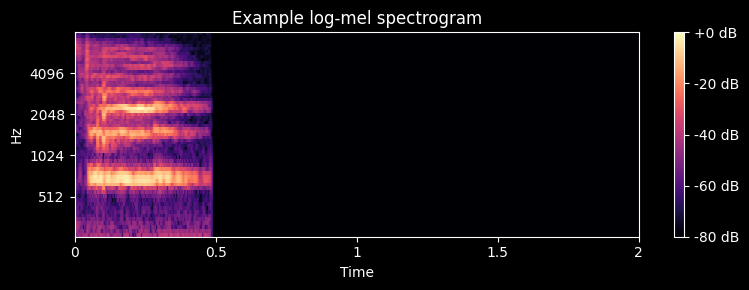

In [12]:
example_path = df_meta["filepath"].iloc[0]
y = load_audio_fixed(example_path)
mel = audio_to_mel(y)
print("Wave shape:", y.shape)
print("Mel shape:", mel.shape)

plt.figure(figsize=(8, 3))
librosa.display.specshow(mel, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                         x_axis="time", y_axis="mel", fmin=FMIN, fmax=FMAX)
plt.colorbar(format="%+2.0f dB")
plt.title("Example log-mel spectrogram")
plt.tight_layout()
plt.show()

In [13]:
df_meta.head()

,filepath,age,cat_id,age_group
0,/Users/brianslonim/PycharmProjects/deep_purrin...,6.0,002A,1
1,/Users/brianslonim/PycharmProjects/deep_purrin...,10.0,028A,1
2,/Users/brianslonim/PycharmProjects/deep_purrin...,3.0,070A,1
3,/Users/brianslonim/PycharmProjects/deep_purrin...,6.0,033A,1
4,/Users/brianslonim/PycharmProjects/deep_purrin...,2.0,000B,1


In [14]:
def build_spectrogram_dataset(df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    specs = []
    labels = []
    groups = []

    for _, row in df.iterrows():
        y = load_audio_fixed(row["filepath"])
        mel = audio_to_mel(y)
        specs.append(mel)
        labels.append(row["age_group"])
        groups.append(row["cat_id"])

    X = np.stack(specs, axis=0)
    y = np.array(labels, dtype=np.int64)
    g = np.array(groups)
    return X, y, g

X, y, groups = build_spectrogram_dataset(df_meta)

print("X shape (before channel):", X.shape)
# add channel dim for CNN: (N, n_mels, time, 1)
X = X[..., np.newaxis]
print("X shape (with channel):", X.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)

X shape (before channel): (793, 64, 751)
X shape (with channel): (793, 64, 751, 1)
y shape: (793,)
groups shape: (793,)


In [15]:
from sklearn.model_selection import GroupShuffleSplit

# Split at cat level so no individual cat appears in both train and test
gss_test = GroupShuffleSplit(n_splits=1, test_size=TEST_SPLIT, random_state=SEED)
train_val_idx, test_idx = next(gss_test.split(X, y, groups=groups))

X_temp, X_test = X[train_val_idx], X[test_idx]
y_temp, y_test = y[train_val_idx], y[test_idx]
groups_temp = groups[train_val_idx]

val_size_rel = VAL_SPLIT / (1 - TEST_SPLIT)  # relative to remaining data
gss_val = GroupShuffleSplit(n_splits=1, test_size=val_size_rel, random_state=SEED)
train_idx, val_idx = next(gss_val.split(X_temp, y_temp, groups=groups_temp))

X_train, X_val = X_temp[train_idx], X_temp[val_idx]
y_train, y_val = y_temp[train_idx], y_temp[val_idx]

print("Train/Val/Test sizes:", X_train.shape[0], X_val.shape[0], X_test.shape[0])

# Verify no cat_id overlap between train and test
train_cats = set(groups[train_val_idx][train_idx])
test_cats = set(groups[test_idx])
assert len(train_cats & test_cats) == 0, "Leakage! Cats in both train and test."
print("No cat-level leakage confirmed.")

X_train.shape, X_val.shape, X_test.shape

Train/Val/Test sizes: 584 73 136
No cat-level leakage confirmed.


((584, 64, 751, 1), (73, 64, 751, 1), (136, 64, 751, 1))

In [16]:
input_shape = X_train.shape[1:]
num_classes = 3

def build_cnn_model(input_shape, num_classes: int) -> keras.Model:
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.4)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="feline_age_spectrogram_cnn")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = build_cnn_model(input_shape, num_classes)
model.summary()

Model: "feline_age_spectrogram_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 751, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 751, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 751, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 375, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 375, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 375, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 375, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 187, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 187, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 187, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 187, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 93, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 93, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,467 (431.51 KB)

 Trainable params: 110,019 (429.76 KB)

 Non-trainable params: 448 (1.75 KB)

In [17]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1024, seed=SEED).batch(BATCH_SIZE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 459ms/step - accuracy: 0.5205 - loss: 1.0336 - val_accuracy: 0.3836 - val_loss: 3.4383 - learning_rate: 0.0010
Epoch 2/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 438ms/step - accuracy: 0.6062 - loss: 0.8727 - val_accuracy: 0.3836 - val_loss: 6.6676 - learning_rate: 0.0010
Epoch 3/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 422ms/step - accuracy: 0.6438 - loss: 0.8115 - val_accuracy: 0.3836 - val_loss: 4.1930 - learning_rate: 0.0010
Epoch 4/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 450ms/step - accuracy: 0.6079 - loss: 0.8352 - val_accuracy: 0.3836 - val_loss: 2.7012 - learning_rate: 5.0000e-04
Epoch 5/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 460ms/step - accuracy: 0.6404 - loss: 0.7843 - val_accuracy: 0.3836 - val_loss: 1.7481 - learning_rate: 5.0000e-04
Epoch 6/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 417ms/step - accuracy: 0.6747 - loss: 0.7352 - val_accuracy: 0.3973 - val_loss: 1.2523 - learning_rate: 5.0000e-04
Epoch 7/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 416ms/step - accuracy: 0.6678 - lo

In [18]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5735 - loss: 0.9638
Test loss: 0.9638
Test accuracy: 0.5735


In [19]:
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
cm

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
              precision    recall  f1-score   support

           0     0.3500    0.5600    0.4308        25
           1     0.7011    0.6932    0.6971        88
           2     0.3333    0.1304    0.1875        23

    accuracy                         0.5735       136
   macro avg     0.4615    0.4612    0.4385       136
weighted avg     0.5744    0.5735    0.5620       136



array([[14, 10,  1],
       [22, 61,  5],
       [ 4, 16,  3]])

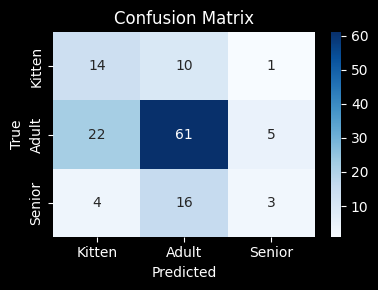

In [21]:
import seaborn as sns

plt.figure(figsize=(4, 3))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Kitten", "Adult", "Senior"],
    yticklabels=["Kitten", "Adult", "Senior"],
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [22]:
# --- Single-audio prediction: run a new meow through the pipeline ---
AGE_GROUP_LABELS = ["Kitten", "Adult", "Senior"]

def predict_age_group(audio_path, model=None):
    """
    Load one audio file, build its spectrogram, and predict age group (Kitten / Adult / Senior).
    Run after training: uses the in-notebook `model` and preprocessing (SAMPLE_RATE, DURATION, etc.).
    audio_path: path to a .wav (or other librosa-supported) file.
    model: optional Keras model; if None, uses the `model` variable from this notebook.
    Returns: (label_str, class_index)
    """
    from pathlib import Path
    audio_path = Path(audio_path)
    if not audio_path.exists():
        raise FileNotFoundError(f"Audio file not found: {audio_path}")

    if model is None:
        model = globals().get("model")
    if model is None:
        raise RuntimeError("No model provided and no trained `model` in notebook. Train the model first.")

    y = load_audio_fixed(audio_path)
    mel = audio_to_mel(y)
    # batch + channel: (1, n_mels, time, 1)
    X = mel[np.newaxis, ..., np.newaxis]

    probs = model.predict(X, verbose=0)
    class_idx = int(np.argmax(probs[0]))
    label = AGE_GROUP_LABELS[class_idx]
    return label, class_idx

# Example (run after training; use your own path for a new file):
# label, idx = predict_age_group("path/to/your/meow.wav")
# print(f"Predicted: {label} (class {idx})")

In [23]:
from pathlib import Path
from tensorflow import keras
# Choose a folder + filename
save_dir = Path("models")
save_dir.mkdir(exist_ok=True)
saved_model_path = save_dir / "cat_spectrogram_cnn.keras"  # or ".h5" if you prefer
model.save(saved_model_path)
print("Saved model to:", saved_model_path)

Saved model to: models/cat_spectrogram_cnn.keras


In [25]:
from tensorflow import keras

saved_model_path = "models/cat_spectrogram_cnn.keras"  # same path as above
saved_model = keras.models.load_model(saved_model_path)

audio_path = r"feline-age-prediction/dataset/raw_audio/AudioCropped/0.5Y-022A-F1-06.wav"
label, idx = predict_age_group(audio_path, model=saved_model)
print(f"Predicted: {label} (class {idx})")

Predicted: Kitten (class 0)
